In [1]:
import os

import numpy as np

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib .pyplot as plt


In [3]:
from research_spring_2025 import get_selected_regions
from research_spring_2025 import generate_h3_grid_from_gdf
from research_spring_2025 import load_us_counties

counties =load_us_counties ()
selected_regions =get_selected_regions ()
h3_cells =generate_h3_grid_from_gdf (selected_regions ,use_cached_file =True )


In [4]:
h3_cells_projected =h3_cells .to_crs ('EPSG:6933')
h3_cell_centroids =h3_cells_projected .centroid
h3_cell_centroids =gpd .GeoDataFrame (geometry =h3_cell_centroids ,crs ='EPSG:6933').to_crs (counties .crs )
h3_cell_centroids ['index']=h3_cells ['index']


In [5]:
cells_with_county_information =gpd .sjoin (h3_cell_centroids ,counties ,how ='left',predicate ='within')

columns_to_keep =['STATEFP','COUNTYFP','ALAND','AWATER']

for column in columns_to_keep :
    h3_cells [column ]=counties .iloc [cells_with_county_information ['index_right']][column ].values


In [6]:
h3_cells ['TRACTFP']=pd .Series (dtype ='string')


In [7]:
tract_data_base_path =Path ('/Users/aaronspaulding/Documents/PycharmProjects/research_spring_2024/data/2020_tracts/')

unique_states =h3_cells .STATEFP .unique ()

for state in unique_states :
    tract_path =tract_data_base_path /f'tl_2020_{state}_tract.shp'
    tracts =gpd .read_file (tract_path )

    tract_path =tract_data_base_path /f'tl_2020_{state}_tract.shp'
    tracts =gpd .read_file (tract_path ).to_crs (counties .crs )

    cells_with_tract_information =gpd .sjoin (h3_cell_centroids ,tracts ,how ='left',predicate ='within')

    mask =(h3_cells ['STATEFP']==state )&(~cells_with_tract_information ['index_right'].isna ())
    h3_cells .loc [mask ,'TRACTFP']=cells_with_tract_information .loc [mask ,'TRACTCE'].values


In [31]:
h3_cells =h3_cells [['STATEFP','COUNTYFP','TRACTFP','ALAND','AWATER','index','geometry']]
h3_cells ['GEOID']=h3_cells ['STATEFP']+h3_cells ['COUNTYFP']+h3_cells ['TRACTFP']


 # Census Data


In [9]:
VARIABLES_TO_DOWNLOAD ={
'B01001_001E':'TOTAL POPULATION',
'B19001_001E':'TOTAL NUMBER OF HOUSEHOLDS',
'B19013_001E':'MEDIAN HOUSEHOLD INCOME',
'B19001_002E':'Households: Less than $10,000',
'B19001_003E':'Households: $10,000 to $14,999',
'B19001_004E':'Households: $15,000 to $19,999',
'B19001_005E':'Households: $20,000 to $24,999',
'B19001_006E':'Households: $25,000 to $29,999',
'B19001_007E':'Households: $30,000 to $34,999',
'B19001_008E':'Households: $35,000 to $39,999',
'B19001_009E':'Households: $40,000 to $44,999',
'B19001_010E':'Households: $45,000 to $49,999',
'B19001_011E':'Households: $50,000 to $59,999',
'B19001_012E':'Households: $60,000 to $74,999',
'B19001_013E':'Households: $75,000 to $99,999',
'B19001_014E':'Households: $100,000 to $124,999',
'B19001_015E':'Households: $125,000 to $149,999',
'B19001_016E':'Households: $150,000 to $199,999',
'B19001_017E':'Households: $200,000 or more'
}


In [10]:
from research_spring_2025 import load_census_data

census_data =load_census_data ()

census_data ['GEOID']=census_data ['state']+census_data ['county']+census_data ['tract']
census_data =census_data .drop (columns =['state','county','tract'])


In [34]:
h3_cells =h3_cells .merge (census_data ,how ='left',on ='GEOID')


In [43]:
GEOIDs ,GEOID_counts =np .unique (h3_cells ['GEOID'],return_counts =True )
geoid_counts =pd .DataFrame (
{
'GEOID':GEOIDs ,
'GEOID_counts':GEOID_counts ,
}
)
h3_cells =h3_cells .merge (geoid_counts ,how ='left',on ='GEOID')


In [69]:
h3_cells ['Total Population Scaled']=h3_cells ['B01001_001E']/h3_cells ['GEOID_counts']
h3_cells ['TOTAL NUMBER OF HOUSEHOLDS Scaled']=h3_cells ['B19001_001E']/h3_cells ['GEOID_counts']
h3_cells ['Households: Less than $10,000 scaled']=h3_cells ['B19001_002E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $10,000 to $14,999 scaled']=h3_cells ['B19001_003E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $15,000 to $19,999 scaled']=h3_cells ['B19001_004E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $20,000 to $24,999 scaled']=h3_cells ['B19001_005E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $25,000 to $29,999 scaled']=h3_cells ['B19001_006E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $30,000 to $34,999 scaled']=h3_cells ['B19001_007E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $35,000 to $39,999 scaled']=h3_cells ['B19001_008E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $40,000 to $44,999 scaled']=h3_cells ['B19001_009E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $45,000 to $49,999 scaled']=h3_cells ['B19001_010E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $50,000 to $59,999 scaled']=h3_cells ['B19001_011E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $60,000 to $74,999 scaled']=h3_cells ['B19001_012E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $75,000 to $99,999 scaled']=h3_cells ['B19001_013E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $100,000 to $124,999 scaled']=h3_cells ['B19001_014E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $125,000 to $149,999 scaled']=h3_cells ['B19001_015E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $150,000 to $199,999 scaled']=h3_cells ['B19001_016E']/h3_cells ['GEOID_counts']
h3_cells ['Households: $200,000 or more scaled']=h3_cells ['B19001_017E']/h3_cells ['GEOID_counts']

assert h3_cells ['B01001_001E'].min ()>=0.
assert h3_cells ['B19001_001E'].min ()>=0.


In [70]:
h3_cells .drop (columns =['geometry','GEOID']).reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_fips_and_census.feather')


In [52]:
h3_cells [h3_cells ['STATEFP']=='09']['Total Population Scaled'].max ()


5843.0

In [ ]:
ct_cells


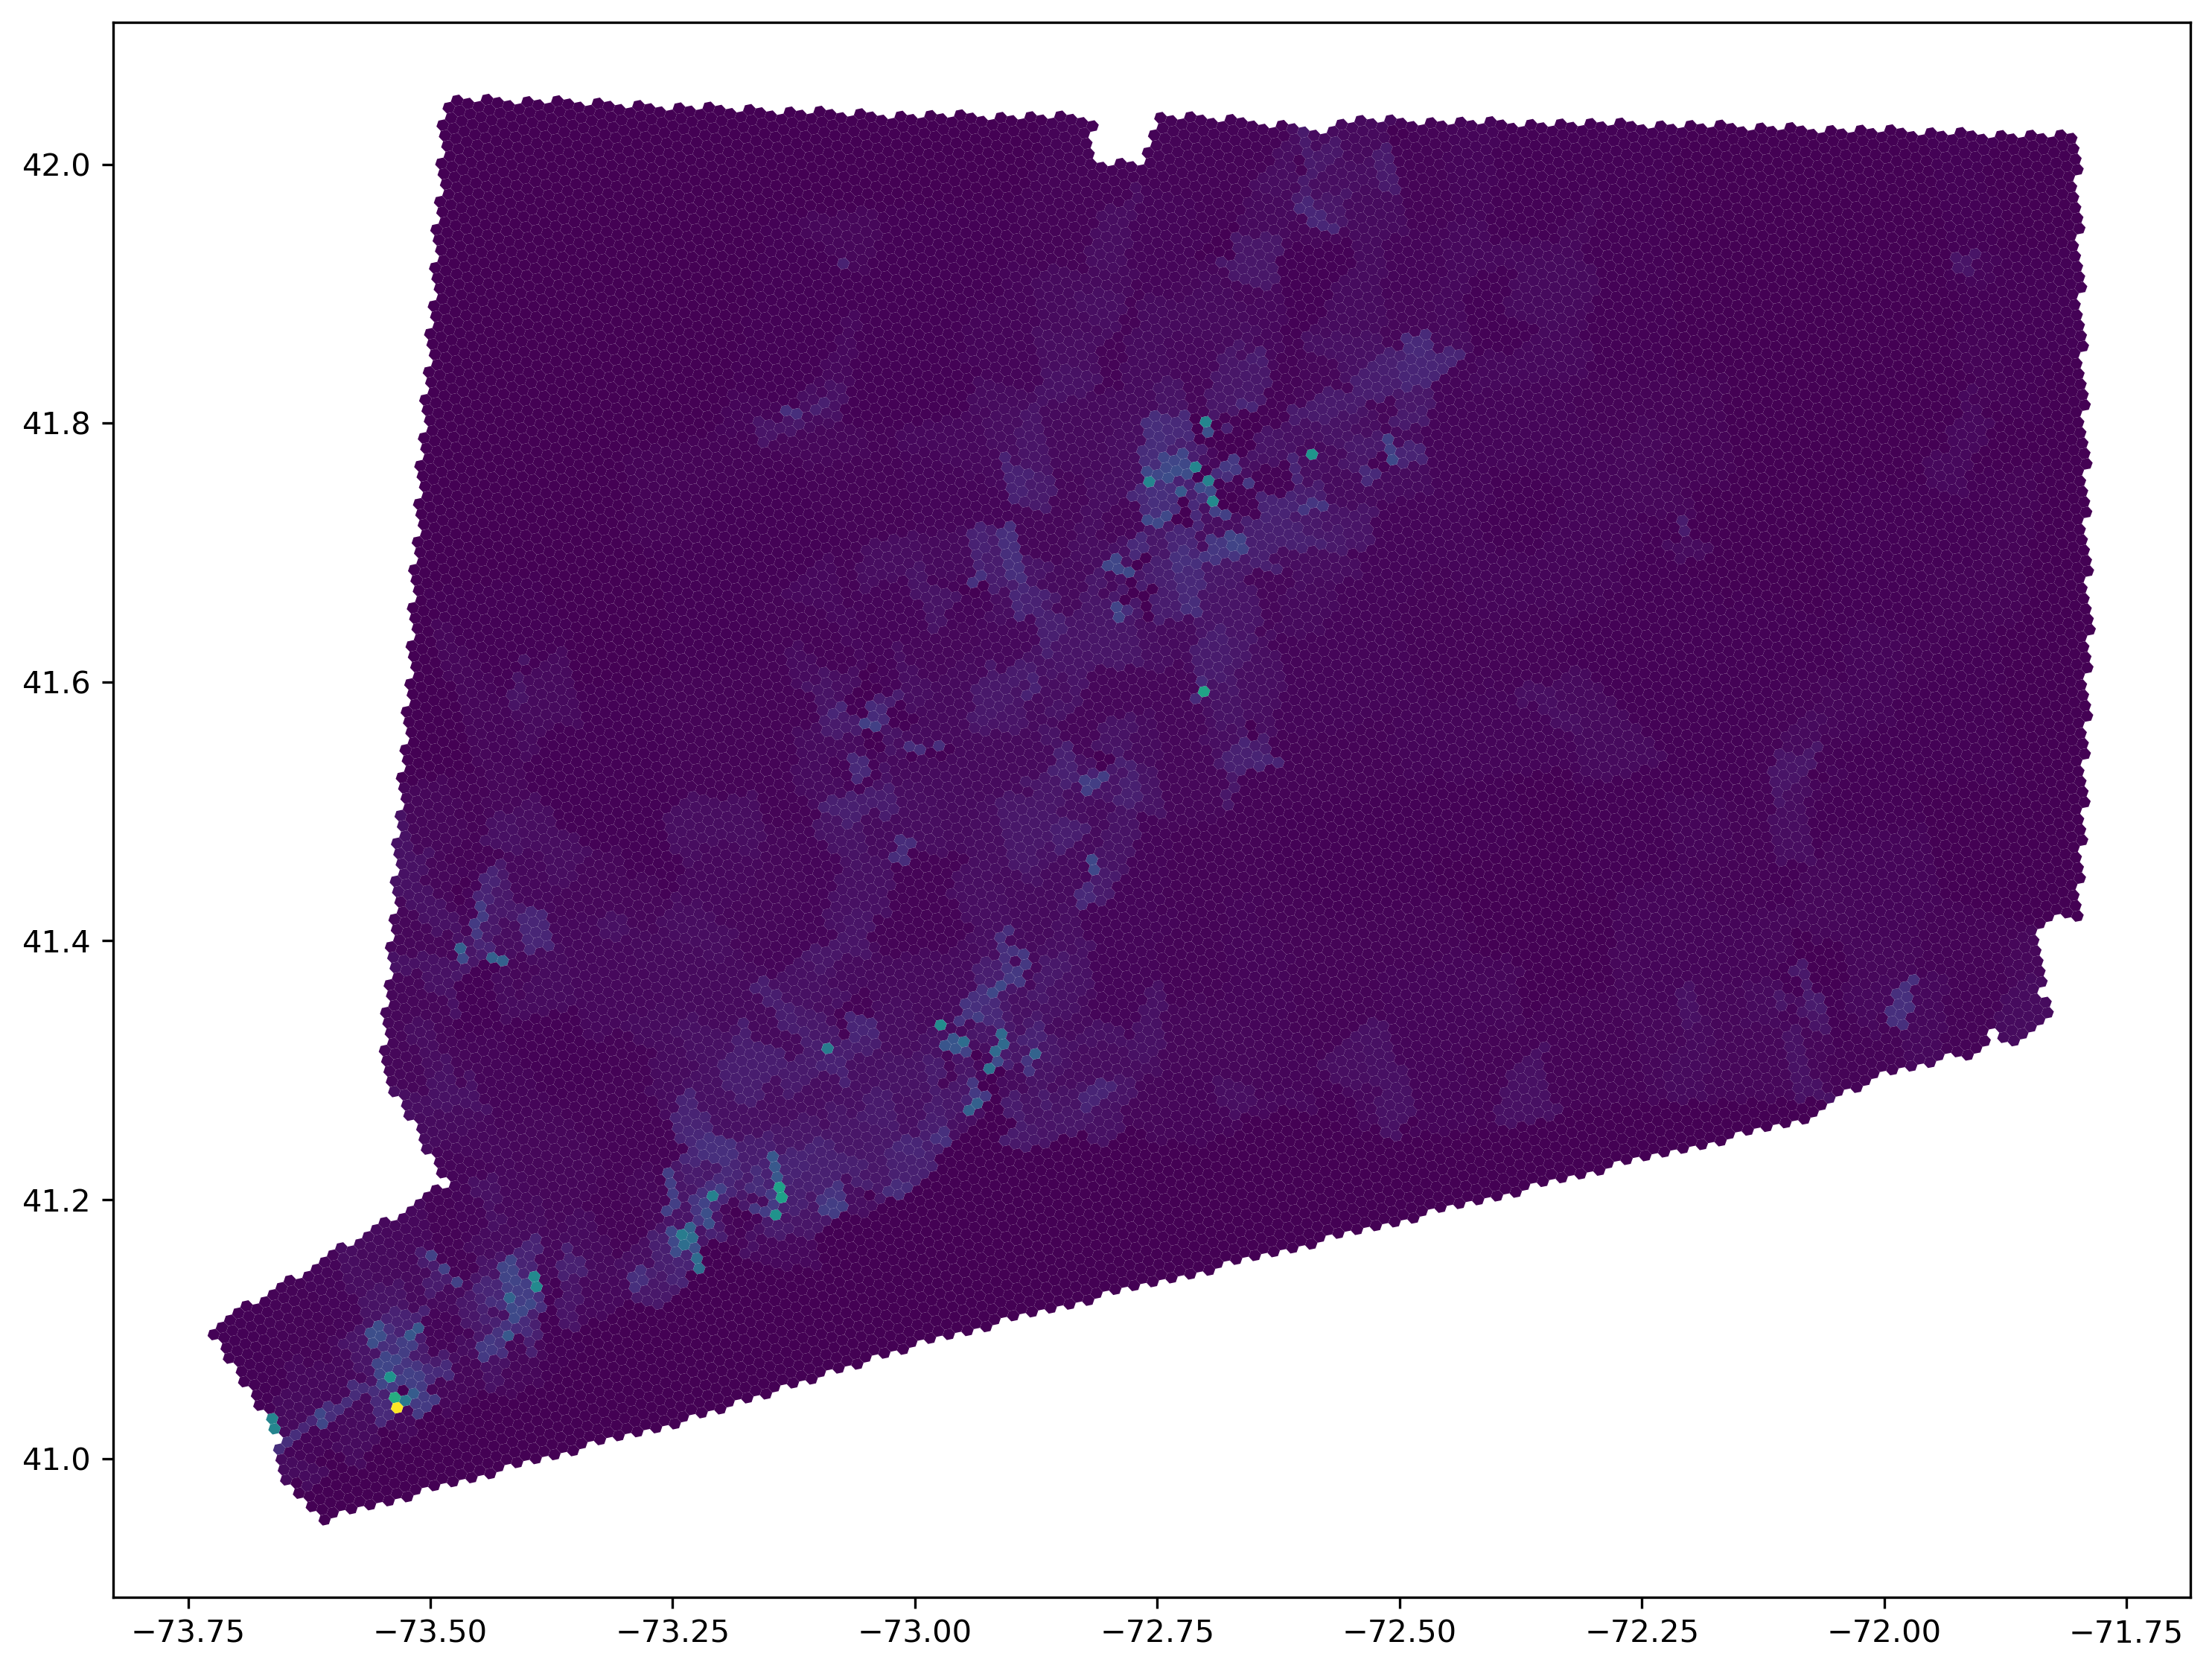

In [68]:
fig ,ax =plt .subplots (figsize =(12 ,10 ),dpi =300 )

ct_cells =h3_cells [h3_cells ['STATEFP']=='09'].copy ()

ct_cells ['Total Population Scaled Log']=np .log1p (ct_cells ['Total Population Scaled'])

ct_cells .plot (
ax =ax ,

column ='Households: $150,000 to $199,999 scaled',
vmin =0
)

plt .show ()


In [26]:
from research_spring_2025 import northeast_fips


In [27]:
northeast_fips


['23', '33', '25', '50', '42', '44', '09', '36']

In [62]:
from research_spring_2025 import northeast_fips

northeast_h3_cells =h3_cells [h3_cells ['STATEFP'].isin (northeast_fips )].copy ()


<Axes: >

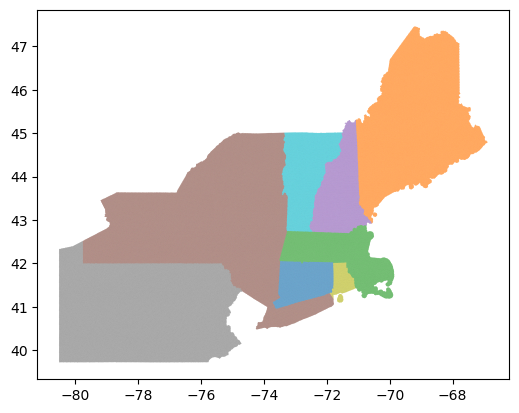

In [63]:
northeast_h3_cells .plot (
column ='STATEFP',
)
